In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

if torch.cuda.is_available():
    print(f"Ekran Kartı: {torch.cuda.get_device_name(0)}")

Kullanılan Cihaz: cuda
Ekran Kartı: NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
DATA_PATH = "tr_signLanguage_dataset"
TRAIN_DIR = os.path.join(DATA_PATH, "train")
TEST_DIR = os.path.join(DATA_PATH, "test")

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_train_data = datasets.ImageFolder(root=TRAIN_DIR)

train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_indices, val_indices = random_split(range(len(full_train_data)), [train_size, val_size])

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

train_dataset = ApplyTransform(torch.utils.data.Subset(full_train_data, train_indices), transform=train_transform)
val_dataset = ApplyTransform(torch.utils.data.Subset(full_train_data, val_indices), transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transform)

classes = full_train_data.classes
num_classes = len(classes)

print(f"Toplam Sinif Sayisi: {num_classes}")
print(f"Sinif Isimleri: {classes}")
print(f"Egitim Seti: {len(train_dataset)}")
print(f"Dogrulama Seti: {len(val_dataset)}")
print(f"Test Seti: {len(test_dataset)}")

Toplam Sinif Sayisi: 26
Sinif Isimleri: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']
Egitim Seti: 95520
Dogrulama Seti: 23880
Test Seti: 47796


In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batch sayisi: {len(train_loader)}")
print(f"Validation batch sayisi: {len(val_loader)}")
print(f"Test batch sayisi: {len(test_loader)}")


Train batch sayisi: 1493
Validation batch sayisi: 374
Test batch sayisi: 747


In [7]:
resnet18 = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet18.parameters():
    param.requires_grad = False

num_ftrs_resnet = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs_resnet, num_classes)
resnet18 = resnet18.to(device)

densenet121 = models.densenet121(weights='IMAGENET1K_V1')
for param in densenet121.parameters():
    param.requires_grad = False

num_ftrs_dense = densenet121.classifier.in_features
densenet121.classifier = nn.Linear(num_ftrs_dense, num_classes)
densenet121 = densenet121.to(device)

print("Modeller basariyla yuklendi ve cikis katmanlari 29 sinifa gore guncellendi.")

Modeller basariyla yuklendi ve cikis katmanlari 29 sinifa gore guncellendi.


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')
        
    return history

def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm}

In [20]:
from torchvision.models import resnet18, ResNet18_Weights

resnet18_configs = [
    {"lr": 0.001,  "batch": 64, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "adam"},
    {"lr": 0.0003, "batch": 128, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "sgd"}
]

results_resnet18 = []

def build_resnet18(dropout=0.5, freeze=True):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, num_classes)
    )
    return model.to(device)

def get_opt(model, lr, opt):
    if opt == "adam": return optim.Adam(model.fc.parameters(), lr=lr)
    if opt == "sgd":  return optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9)

for i, cfg in enumerate(resnet18_configs, start=1):
    print(f"\n============== ResNet18 Tuning {i}/4 ==============")
    print(cfg)

    tuning_train_loader = DataLoader(train_dataset, batch_size=cfg["batch"], shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    tuning_val_loader = DataLoader(val_dataset, batch_size=cfg["batch"], shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = build_resnet18(dropout=0.5, freeze=True)
    optimizer = get_opt(model, cfg["lr"], cfg["opt"])
    criterion = nn.CrossEntropyLoss()

    history = train_model(
        model,
        tuning_train_loader,
        tuning_val_loader,
        criterion,
        optimizer,
        epochs=3
    )

    best_val_acc = max(history["val_acc"])
    results_resnet18.append((cfg, best_val_acc))

print("\n==================== ResNet18 Tuning Sonuclari ====================")
for r in results_resnet18:
    print(r)


============== ResNet18 Tuning 1/4 ==============
{'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 1.7526, Acc: 0.4731 | Val Loss: 1.0900, Acc: 0.6778
Epoch 2/3 - Train Loss: 1.5546, Acc: 0.5219 | Val Loss: 1.0219, Acc: 0.6970
Epoch 3/3 - Train Loss: 1.5483, Acc: 0.5239 | Val Loss: 1.0063, Acc: 0.7002

============== ResNet18 Tuning 2/4 ==============
{'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 1.8925, Acc: 0.4400 | Val Loss: 1.1705, Acc: 0.6835
Epoch 2/3 - Train Loss: 1.5138, Acc: 0.5351 | Val Loss: 1.0419, Acc: 0.7119
Epoch 3/3 - Train Loss: 1.4944, Acc: 0.5396 | Val Loss: 0.9938, Acc: 0.7246

============== ResNet18 Tuning 3/4 ==============
{'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 2.2563, Acc: 0.3491 | Val Loss: 1.4363, Acc: 0.6495
Epoch 2/3 - Train Loss: 1.5976, Acc: 0.5216 | Val Loss: 1.2010, Acc: 0.6846
Epoch 3/3 - Train Loss: 1.5009, Acc: 0.5426 | Val Loss: 1.0963, Acc: 0.7086

============== ResNet18 Tuning 4/

In [21]:
best_cfg = {"lr": 0.0005, "batch": 64, "opt": "adam"}

train_loader = DataLoader(train_dataset, batch_size=best_cfg["batch"], shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=best_cfg["batch"], shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

final_resnet18 = build_resnet18(dropout=0.5, freeze=True)
optimizer_final = get_opt(final_resnet18, best_cfg["lr"], best_cfg["opt"])
criterion = nn.CrossEntropyLoss()

print(f"En iyi konfigurasyon ile Final Freeze Egitim basliyor: {best_cfg}")

resnet18_freeze_history = train_model(
    model=final_resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_final,
    epochs=10
)

En iyi konfigurasyon ile Final Freeze Egitim basliyor: {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/10 - Train Loss: 1.8999, Acc: 0.4392 | Val Loss: 1.1526, Acc: 0.6884
Epoch 2/10 - Train Loss: 1.5164, Acc: 0.5335 | Val Loss: 1.0272, Acc: 0.7172
Epoch 3/10 - Train Loss: 1.4958, Acc: 0.5373 | Val Loss: 1.0188, Acc: 0.7149
Epoch 4/10 - Train Loss: 1.4945, Acc: 0.5385 | Val Loss: 0.9738, Acc: 0.7240
Epoch 5/10 - Train Loss: 1.4961, Acc: 0.5392 | Val Loss: 0.9810, Acc: 0.7170
Epoch 6/10 - Train Loss: 1.4945, Acc: 0.5361 | Val Loss: 0.9524, Acc: 0.7342
Epoch 7/10 - Train Loss: 1.4835, Acc: 0.5427 | Val Loss: 0.9988, Acc: 0.7112
Epoch 8/10 - Train Loss: 1.4881, Acc: 0.5401 | Val Loss: 0.9767, Acc: 0.7183
Epoch 9/10 - Train Loss: 1.4937, Acc: 0.5397 | Val Loss: 0.9835, Acc: 0.7193
Epoch 10/10 - Train Loss: 1.4947, Acc: 0.5383 | Val Loss: 0.9715, Acc: 0.7235


In [22]:
for param in final_resnet18.parameters():
    param.requires_grad = True

optimizer_fine = optim.Adam(final_resnet18.parameters(), lr=0.0001)

print("Tum katmanlar egitime acildi. Fine-Tuning basliyor...")

resnet18_fine_history = train_model(
    model=final_resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fine,
    epochs=5
)

Tum katmanlar egitime acildi. Fine-Tuning basliyor...
Epoch 1/5 - Train Loss: 0.1339, Acc: 0.9582 | Val Loss: 0.0156, Acc: 0.9952
Epoch 2/5 - Train Loss: 0.0242, Acc: 0.9926 | Val Loss: 0.0109, Acc: 0.9967
Epoch 3/5 - Train Loss: 0.0199, Acc: 0.9939 | Val Loss: 0.0110, Acc: 0.9962
Epoch 4/5 - Train Loss: 0.0158, Acc: 0.9953 | Val Loss: 0.0239, Acc: 0.9937
Epoch 5/5 - Train Loss: 0.0140, Acc: 0.9959 | Val Loss: 0.0095, Acc: 0.9970


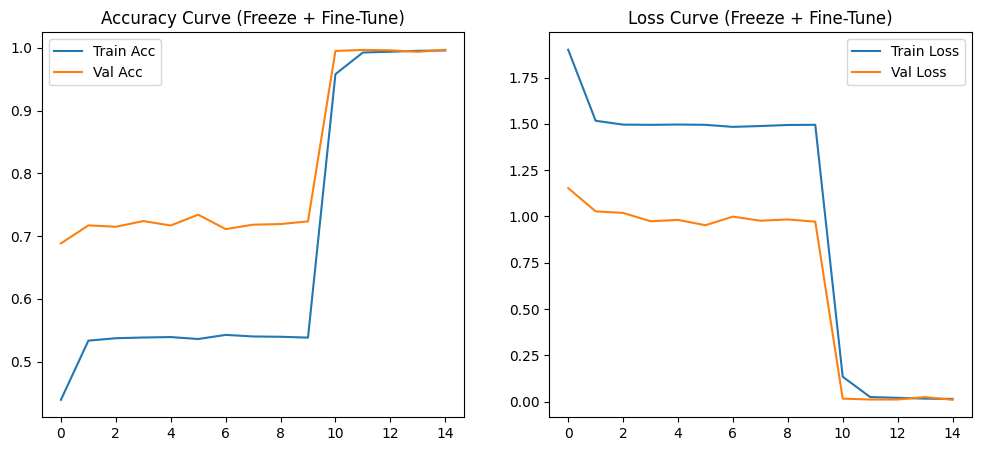

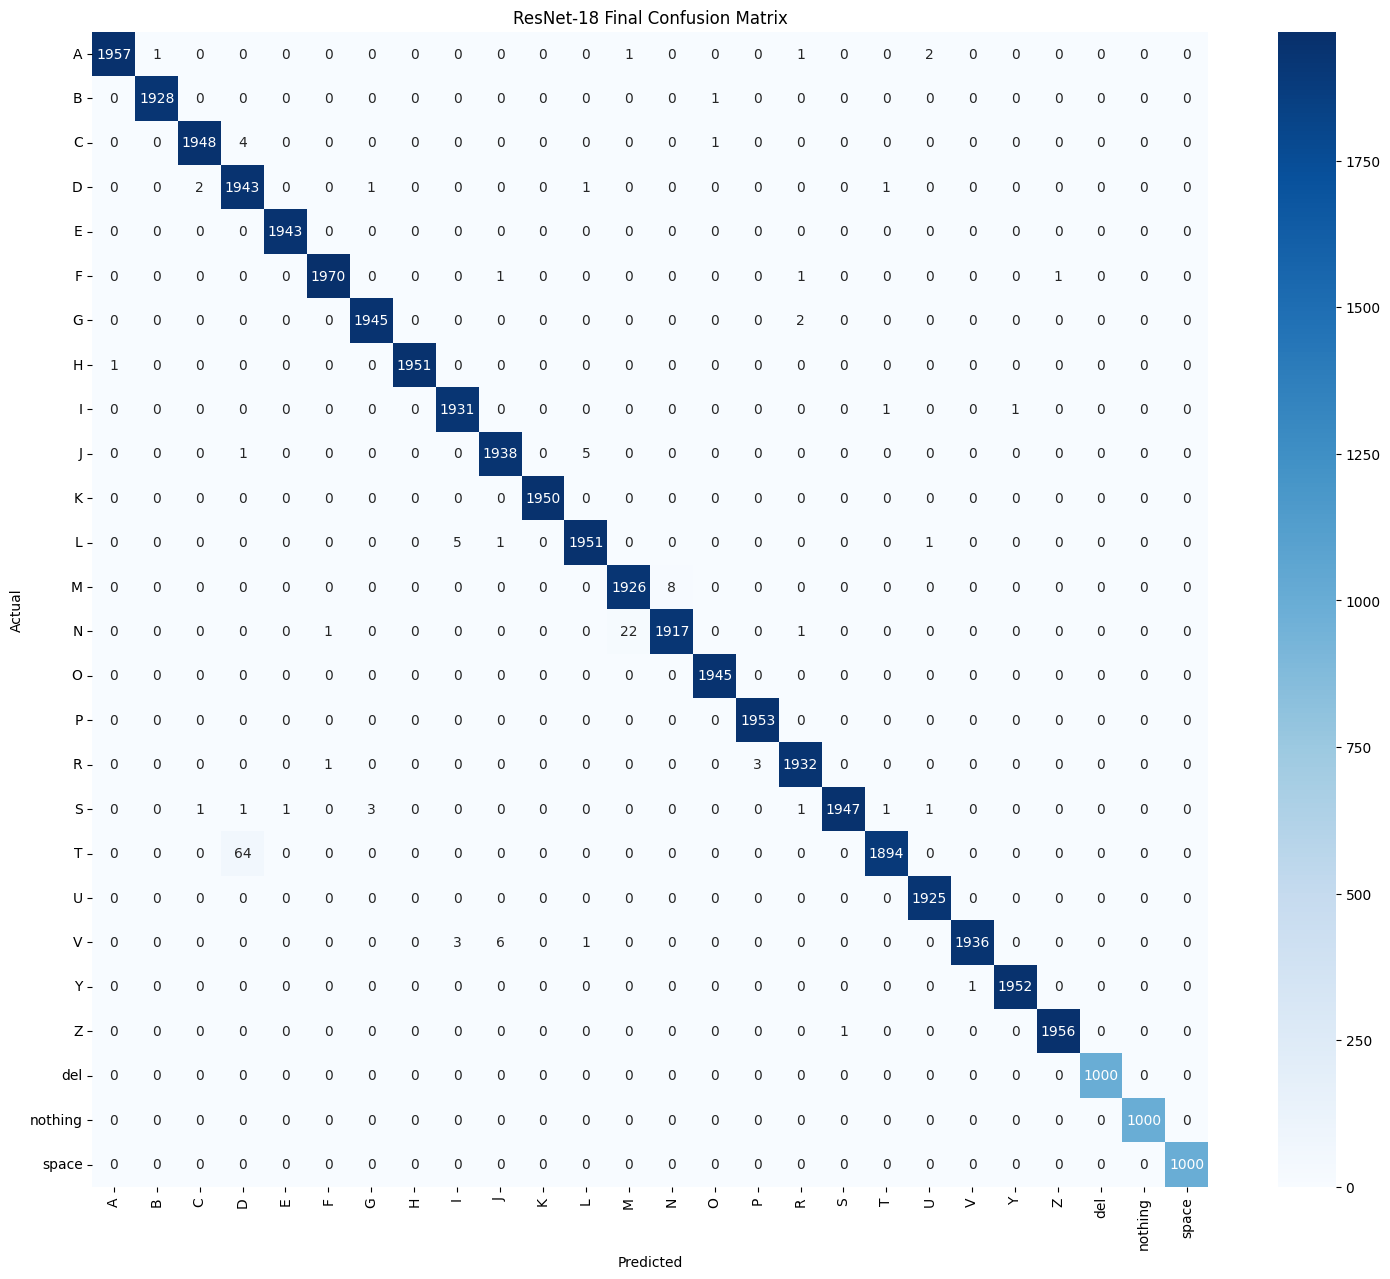


--- SINIF BAZLI BASARIM RAPORU ---
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1962
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       0.97      1.00      0.98      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.00      1.00      1953
           R       1.00      1.00      1.00  

In [23]:
final_results = evaluate_model(final_resnet18, test_loader)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(resnet18_freeze_history['train_acc'] + resnet18_fine_history['train_acc'], label='Train Acc')
plt.plot(resnet18_freeze_history['val_acc'] + resnet18_fine_history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve (Freeze + Fine-Tune)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(resnet18_freeze_history['train_loss'] + resnet18_fine_history['train_loss'], label='Train Loss')
plt.plot(resnet18_freeze_history['val_loss'] + resnet18_fine_history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Freeze + Fine-Tune)')
plt.legend()
plt.savefig('EMRULLAH_YILDIZ_ResNet18_Curves.png')
plt.show()

plt.figure(figsize=(18, 15))
sns.heatmap(final_results['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('ResNet-18 Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('EMRULLAH_YILDIZ_ResNet18_ConfusionMatrix.png')
plt.show()

model_save_name = "EMRULLAH_YILDIZ_23040301101_DeepSign_ResNet18.pth"
torch.save(final_resnet18.state_dict(), model_save_name)

report_text = f"""
Model Adi: ResNet-18
Freeze Train Accuracy: {resnet18_freeze_history['train_acc'][-1]:.4f}
Freeze Val Accuracy: {resnet18_freeze_history['val_acc'][-1]:.4f}
Fine-Tune Test Accuracy: {final_results['acc']:.4f}
Macro Precision: {final_results['prec']:.4f}
Macro Recall: {final_results['rec']:.4f}
Macro F1: {final_results['f1']:.4f}
Training Epoch Sayisi: 10 (Freeze) + 5 (Fine-Tune)
En iyi LR / Batch / Optimizer: {best_cfg['lr']} / {best_cfg['batch']} / {best_cfg['opt']}
"""

with open("ResNet18_Final_Sonuclar.txt", "w") as f:
    f.write(report_text)

print("\n--- SINIF BAZLI BASARIM RAPORU ---")
y_true_test = []
y_pred_test = []
final_resnet18.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_resnet18(images)
        _, preds = outputs.max(1)
        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(preds.cpu().numpy())

print(classification_report(y_true_test, y_pred_test, target_names=classes, zero_division=0))
print(f"\nTum metrikler, grafikler ve {model_save_name} basariyla kaydedildi.")

In [10]:
import torch.optim as optim

def get_opt(model, lr, opt):
    if opt == "adam": 
        return optim.Adam(model.parameters(), lr=lr)
    if opt == "sgd":  
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

def build_densenet121(dropout=0.5, freeze=True):
    from torchvision.models import densenet121, DenseNet121_Weights
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    
    # DenseNet'te classifier katmanini degistiriyoruz
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, len(classes)) # 'classes' listesi yukarida tanimli olmali
    )
    return model.to(device)

In [11]:
from torchvision.models import densenet121, DenseNet121_Weights
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

densenet_configs = [
    {"lr": 0.001,  "batch": 64, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "adam"},
    {"lr": 0.0003, "batch": 128, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "sgd"}
]

results_densenet = []

def build_densenet121(dropout=0.5, freeze=True):
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, num_classes)
    )
    return model.to(device)

for i, cfg in enumerate(densenet_configs, start=1):
    print(f"\n============== DenseNet121 Tuning {i}/4 ==============")
    print(cfg)

    tuning_loader = DataLoader(train_dataset, batch_size=cfg["batch"], shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    tuning_val_loader = DataLoader(val_dataset, batch_size=cfg["batch"], shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = build_densenet121(dropout=0.5, freeze=True)
    optimizer = get_opt(model, cfg["lr"], cfg["opt"])
    criterion = nn.CrossEntropyLoss()

    history = train_model(
        model,
        tuning_loader,
        tuning_val_loader,
        criterion,
        optimizer,
        epochs=3
    )

    best_val_acc = max(history["val_acc"])
    results_densenet.append((cfg, best_val_acc))

print("\n==================== DenseNet121 Tuning Sonuclari ====================")
for r in results_densenet:
    print(r)


============== DenseNet121 Tuning 1/4 ==============
{'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 1.4976, Acc: 0.5485 | Val Loss: 0.8430, Acc: 0.7788
Epoch 2/3 - Train Loss: 1.2801, Acc: 0.6023 | Val Loss: 0.7779, Acc: 0.7755
Epoch 3/3 - Train Loss: 1.2631, Acc: 0.6076 | Val Loss: 0.7416, Acc: 0.7914

============== DenseNet121 Tuning 2/4 ==============
{'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 1.6433, Acc: 0.5206 | Val Loss: 0.9775, Acc: 0.7581
Epoch 2/3 - Train Loss: 1.2582, Acc: 0.6102 | Val Loss: 0.8127, Acc: 0.7841
Epoch 3/3 - Train Loss: 1.2261, Acc: 0.6169 | Val Loss: 0.7644, Acc: 0.7964

============== DenseNet121 Tuning 3/4 ==============
{'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch 1/3 - Train Loss: 1.9911, Acc: 0.4447 | Val Loss: 1.2695, Acc: 0.7214
Epoch 2/3 - Train Loss: 1.3525, Acc: 0.6022 | Val Loss: 1.0021, Acc: 0.7665
Epoch 3/3 - Train Loss: 1.2490, Acc: 0.6223 | Val Loss: 0.8867, Acc: 0.7874

============== DenseNet1

In [12]:
best_dense_cfg = {"lr": 0.0005, "batch": 64, "opt": "adam"}

train_loader = DataLoader(train_dataset, batch_size=best_dense_cfg["batch"], shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=best_dense_cfg["batch"], shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

final_densenet121 = build_densenet121(dropout=0.5, freeze=True)
optimizer_dense_final = get_opt(final_densenet121, best_dense_cfg["lr"], best_dense_cfg["opt"])
criterion = nn.CrossEntropyLoss()

print(f"DenseNet-121 icin Final Freeze Egitim basliyor: {best_dense_cfg}")

dense121_freeze_history = train_model(
    model=final_densenet121,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_dense_final,
    epochs=10
)

DenseNet-121 icin Final Freeze Egitim basliyor: {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/10 - Train Loss: 1.6404, Acc: 0.5201 | Val Loss: 0.9715, Acc: 0.7657
Epoch 2/10 - Train Loss: 1.2674, Acc: 0.6098 | Val Loss: 0.8291, Acc: 0.7897
Epoch 3/10 - Train Loss: 1.2241, Acc: 0.6167 | Val Loss: 0.7794, Acc: 0.7923
Epoch 4/10 - Train Loss: 1.2258, Acc: 0.6155 | Val Loss: 0.7589, Acc: 0.7936
Epoch 5/10 - Train Loss: 1.2061, Acc: 0.6229 | Val Loss: 0.7434, Acc: 0.8044
Epoch 6/10 - Train Loss: 1.2030, Acc: 0.6232 | Val Loss: 0.7409, Acc: 0.7979
Epoch 7/10 - Train Loss: 1.1979, Acc: 0.6257 | Val Loss: 0.7011, Acc: 0.8124
Epoch 8/10 - Train Loss: 1.1975, Acc: 0.6242 | Val Loss: 0.7081, Acc: 0.8106
Epoch 9/10 - Train Loss: 1.1883, Acc: 0.6278 | Val Loss: 0.7084, Acc: 0.8074
Epoch 10/10 - Train Loss: 1.1826, Acc: 0.6292 | Val Loss: 0.7107, Acc: 0.8036


In [13]:
for param in final_densenet121.parameters():
    param.requires_grad = True

optimizer_dense_fine = optim.Adam(final_densenet121.parameters(), lr=0.0001)

print("DenseNet-121: Tum katmanlar egitime acildi. Fine-Tuning basliyor...")

dense121_fine_history = train_model(
    model=final_densenet121,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_dense_fine,
    epochs=5
)

DenseNet-121: Tum katmanlar egitime acildi. Fine-Tuning basliyor...
Epoch 1/5 - Train Loss: 0.1024, Acc: 0.9678 | Val Loss: 0.0065, Acc: 0.9984
Epoch 2/5 - Train Loss: 0.0176, Acc: 0.9947 | Val Loss: 0.0048, Acc: 0.9985
Epoch 3/5 - Train Loss: 0.0150, Acc: 0.9954 | Val Loss: 0.0057, Acc: 0.9983
Epoch 4/5 - Train Loss: 0.0099, Acc: 0.9971 | Val Loss: 0.0059, Acc: 0.9983
Epoch 5/5 - Train Loss: 0.0109, Acc: 0.9968 | Val Loss: 0.0033, Acc: 0.9989


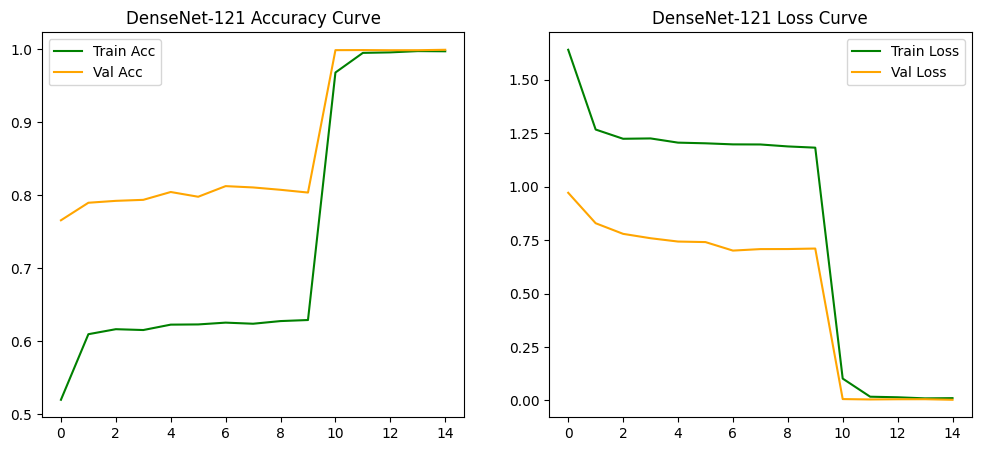

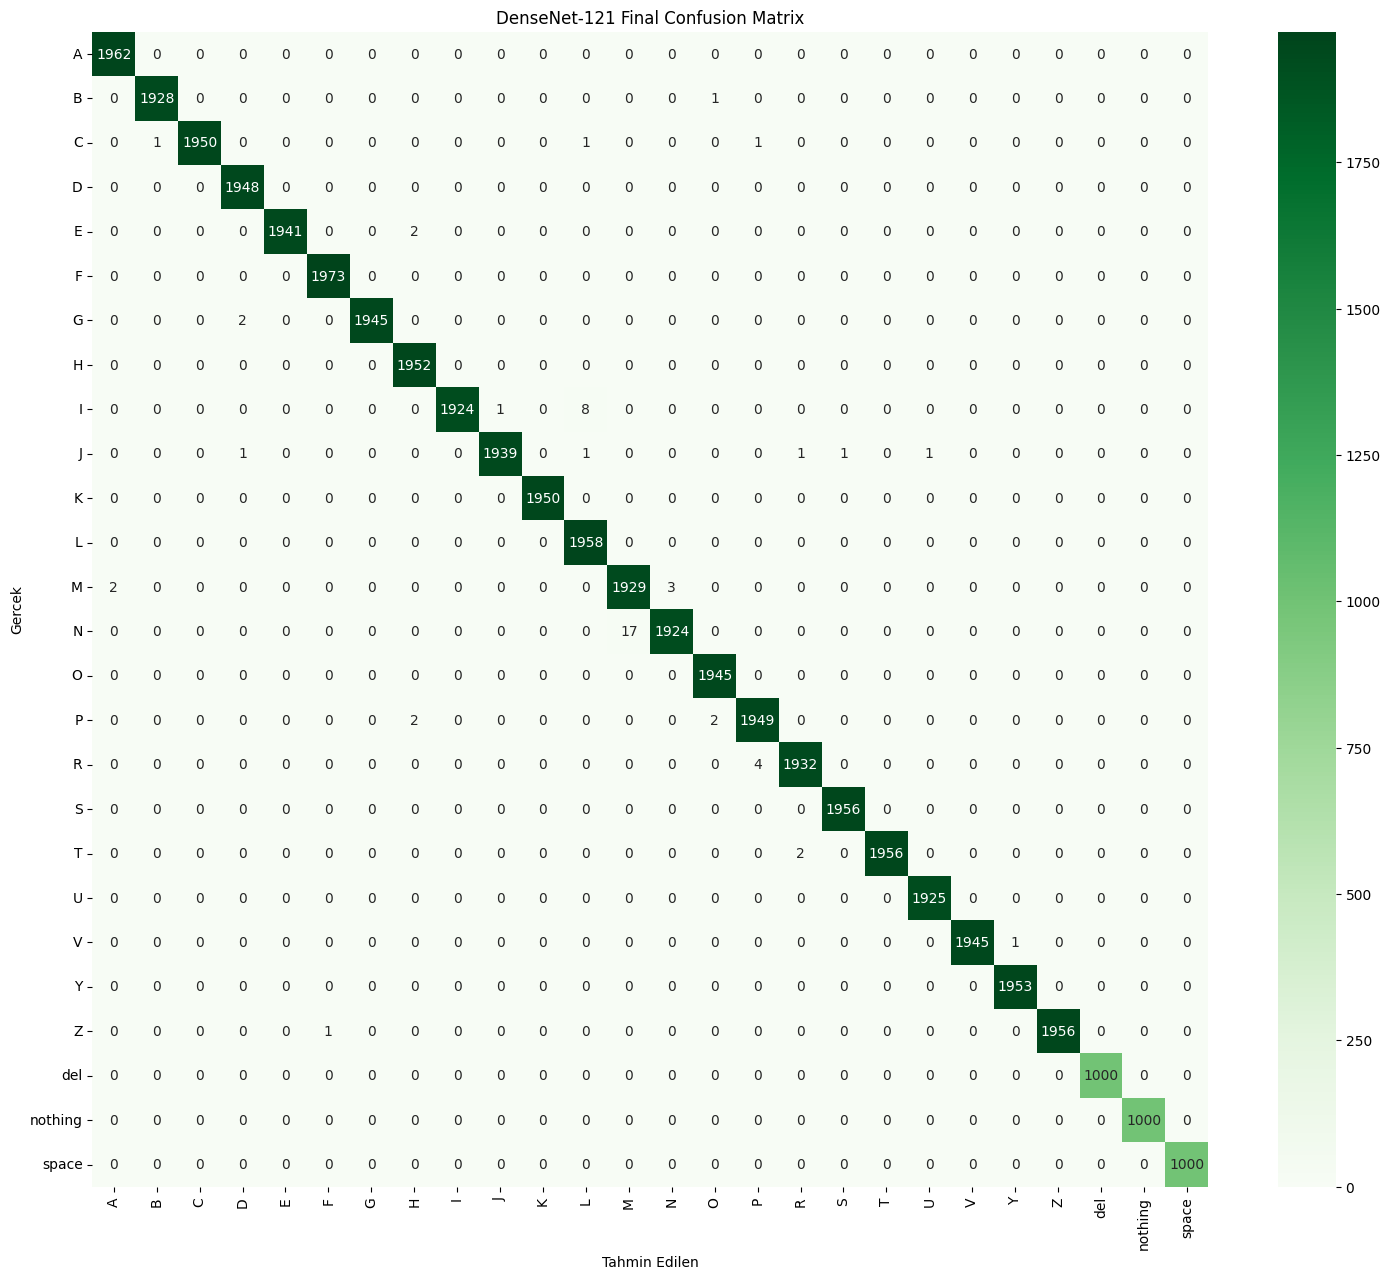


--- ISLEM TAMAMLANDI ---
Model Agirligi: EMRULLAH_YILDIZ_23040301101_DeepSign_DenseNet121.pth kaydedildi.
Grafikler ve Rapor dosyasi olusturuldu.


In [14]:
dense_final_results = evaluate_model(final_densenet121, test_loader)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(dense121_freeze_history['train_acc'] + dense121_fine_history['train_acc'], label='Train Acc', color='green')
plt.plot(dense121_freeze_history['val_acc'] + dense121_fine_history['val_acc'], label='Val Acc', color='orange')
plt.title('DenseNet-121 Accuracy Curve')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dense121_freeze_history['train_loss'] + dense121_fine_history['train_loss'], label='Train Loss', color='green')
plt.plot(dense121_freeze_history['val_loss'] + dense121_fine_history['val_loss'], label='Val Loss', color='orange')
plt.title('DenseNet-121 Loss Curve')
plt.legend()
plt.savefig('EMRULLAH_YILDIZ_DenseNet121_Curves.png')
plt.show()

plt.figure(figsize=(18, 15))
sns.heatmap(dense_final_results['cm'], annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('DenseNet-121 Final Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.savefig('EMRULLAH_YILDIZ_DenseNet121_ConfusionMatrix.png')
plt.show()

dense_model_save_name = "EMRULLAH_YILDIZ_23040301101_DeepSign_DenseNet121.pth"
torch.save(final_densenet121.state_dict(), dense_model_save_name)

dense_report_content = f"""
Model Adi: DenseNet-121
Freeze Train Accuracy: {dense121_freeze_history['train_acc'][-1]:.4f}
Freeze Val Accuracy: {dense121_freeze_history['val_acc'][-1]:.4f}
Fine-Tune Test Accuracy: {dense_final_results['acc']:.4f}
Macro Precision: {dense_final_results['prec']:.4f}
Macro Recall: {dense_final_results['rec']:.4f}
Macro F1: {dense_final_results['f1']:.4f}
Training Epoch Sayisi: 10 (Freeze) + 5 (Fine-Tune)
En iyi LR / Batch / Optimizer: {best_dense_cfg['lr']} / {best_dense_cfg['batch']} / {best_dense_cfg['opt']}
"""

with open("DenseNet121_Final_Sonuclar.txt", "w") as f:
    f.write(dense_report_content)

print("\n--- ISLEM TAMAMLANDI ---")
print(f"Model Agirligi: {dense_model_save_name} kaydedildi.")
print("Grafikler ve Rapor dosyasi olusturuldu.")

DenseNet-121 için final test süreci başladı...

--- DETAYLI SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1962
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       0.99      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.00      1.00      1

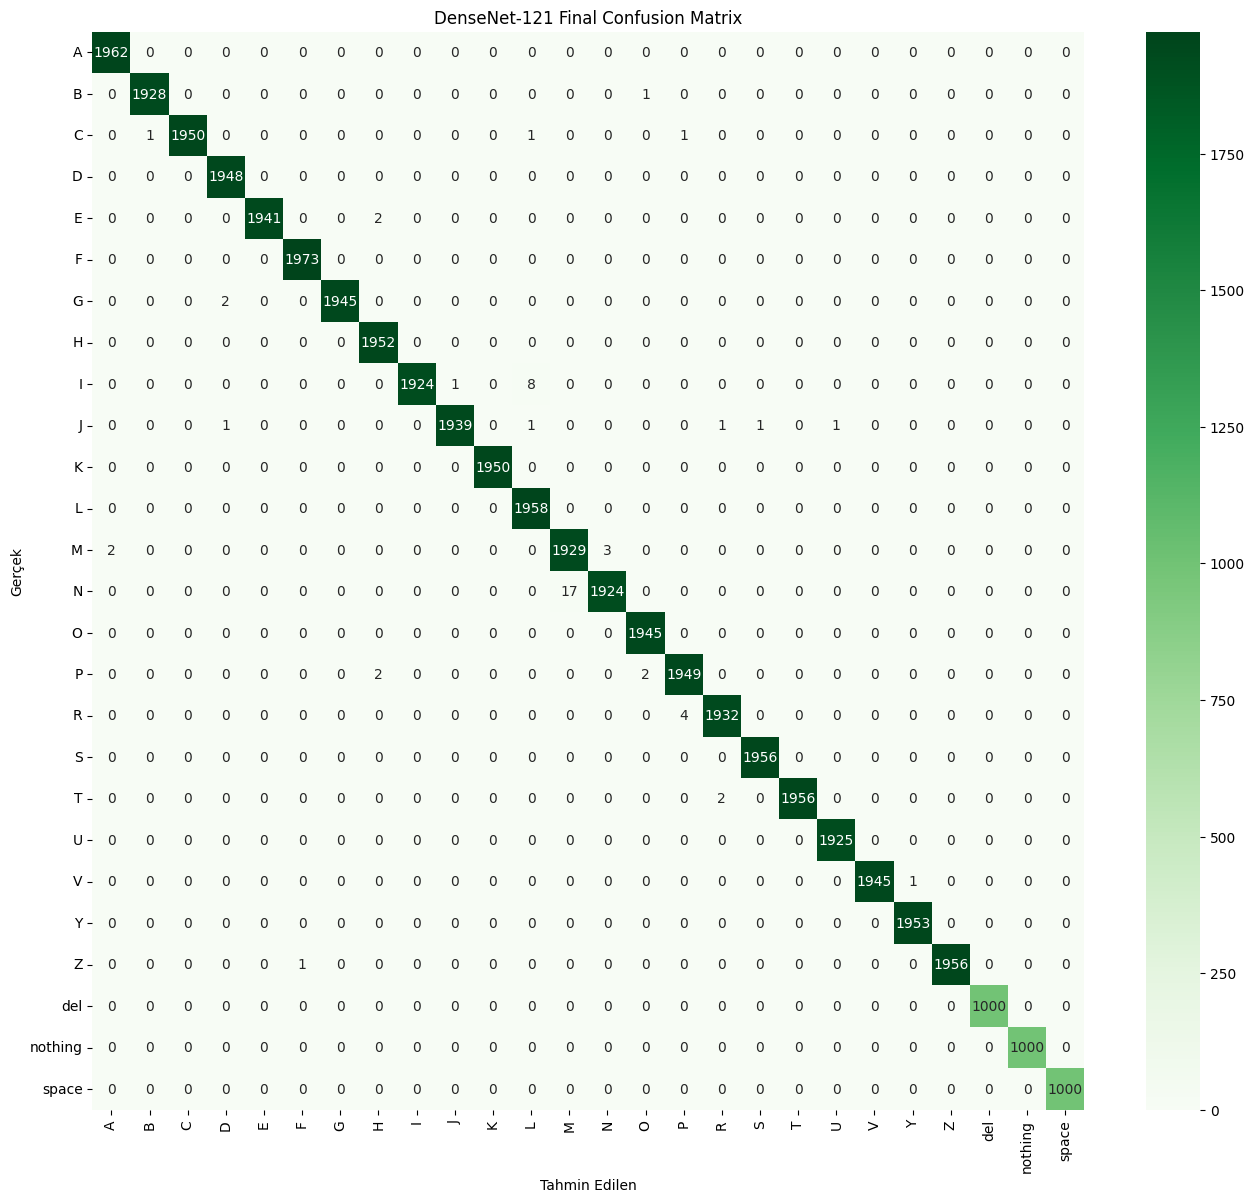

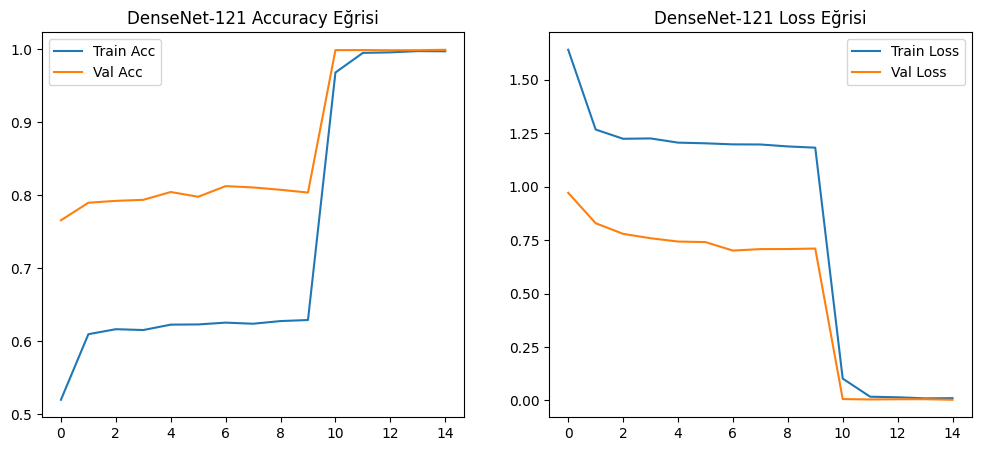


[TAMAMLANDI] Tüm raporlar, grafikler ve .pth dosyası kaydedildi.


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("DenseNet-121 için final test süreci başladı...")
y_true = []
y_pred = []
final_densenet121.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_densenet121(images)
        _, preds = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

report = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
print("\n--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(report)

with open("EMRULLAH_YILDIZ_DenseNet121_Rapor.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('DenseNet-121 Final Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.savefig('EMRULLAH_YILDIZ_DenseNet121_ConfusionMatrix.png')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(dense121_freeze_history['train_acc'] + dense121_fine_history['train_acc'], label='Train Acc')
plt.plot(dense121_freeze_history['val_acc'] + dense121_fine_history['val_acc'], label='Val Acc')
plt.title('DenseNet-121 Accuracy Eğrisi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dense121_freeze_history['train_loss'] + dense121_fine_history['train_loss'], label='Train Loss')
plt.plot(dense121_freeze_history['val_loss'] + dense121_fine_history['val_loss'], label='Val Loss')
plt.title('DenseNet-121 Loss Eğrisi')
plt.legend()
plt.savefig('EMRULLAH_YILDIZ_DenseNet121_Egitim_Grafikleri.png')
plt.show()

torch.save(final_densenet121.state_dict(), "EMRULLAH_YILDIZ_DenseNet121_Final.pth")

print("\n[TAMAMLANDI] Tüm raporlar, grafikler ve .pth dosyası kaydedildi.")